In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
# read in data 
df = pd.read_csv("../data/raw/neo.csv")

In [ ]:
# Relative velocity distribution:
    # - most objects move at "normal" speeds
    # - a few are extremely fast
    # - velocity is a strong risk signal when combined with distance

# Distribution of miss distance
    # - a huge spike at small distances and a long stetched tail
    # - we need to log transform miss distance
    # - raw values will distort models


# Absolute magnitude distribution
    # - most neos are small and faint, a few are large and bright
    # - a good proxy for size (lower h = bigger object

In [9]:
# Feature engineering
## 1. log transforms
df['log_miss_distance'] = np.log1p(df['miss_distance'])
df['log_velocity'] = np.log1p(df['relative_velocity'])

## 2. diameter midpoint (MUST come before kinetic_proxy)
df['diameter_mid'] = (df['est_diameter_min'] + df['est_diameter_max']) / 2

## 3. size × velocity composite
df['kinetic_proxy'] = df['diameter_mid'] * df['relative_velocity']

## 4. z-scores
df['velocity_z'] = (df['relative_velocity'] - df['relative_velocity'].mean()) / df['relative_velocity'].std()
df['distance_z'] = (df['miss_distance'] - df['miss_distance'].mean()) / df['miss_distance'].std()

## 5. preliminary risk score
df['risk_score'] = (
    df['velocity_z'] * 0.4 +
    df['log_miss_distance'] * -0.5 +
    df['diameter_mid'] * 0.1
)


In [10]:
df[['diameter_mid', 'kinetic_proxy', 'risk_score']].head()
 

,diameter_mid,kinetic_proxy,risk_score
0,1.938843,26308.642289,-9.261641
1,0.430073,31648.556395,-8.520149
2,1.168268,133484.815463,-7.698136
3,0.156150,3866.951529,-8.878721
4,0.412613,17634.132763,-8.868079


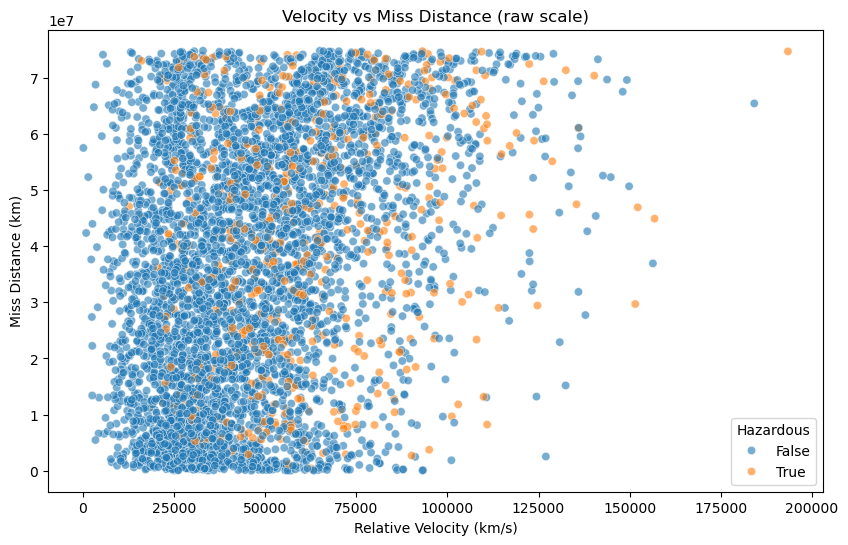

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),  # sample for speed
    x='relative_velocity',
    y='miss_distance',
    hue='hazardous',
    alpha=0.6
)
plt.title("Velocity vs Miss Distance (raw scale)")
plt.xlabel("Relative Velocity (km/s)")
plt.ylabel("Miss Distance (km)")
plt.legend(title="Hazardous")
plt.show()

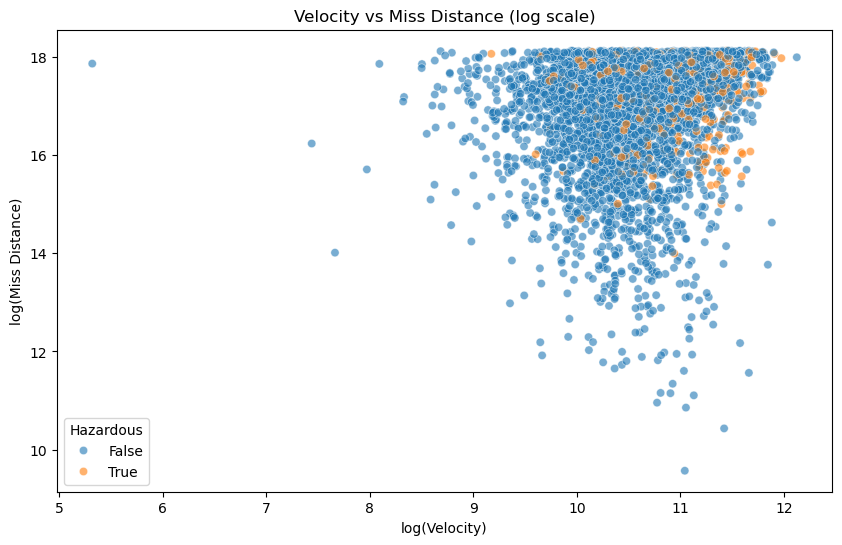

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    hue='hazardous',
    alpha=0.6
)
plt.title("Velocity vs Miss Distance (log scale)")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.legend(title="Hazardous")
plt.show()

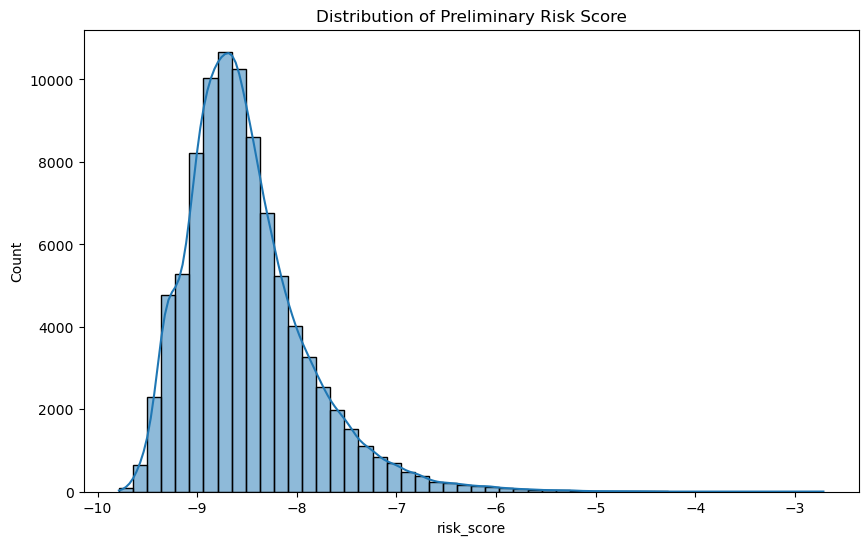

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['risk_score'], bins=50, kde=True)
plt.title("Distribution of Preliminary Risk Score")
plt.show()


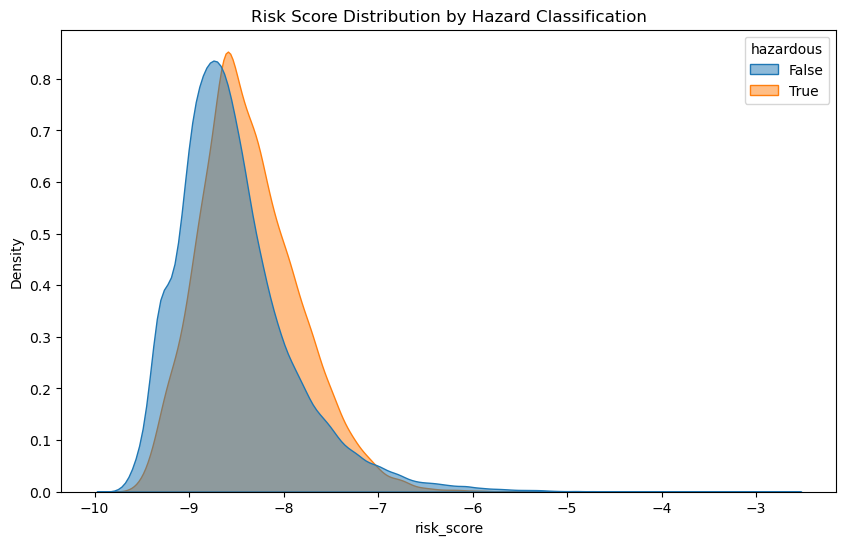

In [14]:
# compare hazardous vs non-hazardous
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x='risk_score',
    hue='hazardous',
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.title("Risk Score Distribution by Hazard Classification")
plt.show()


In [ ]:
# There are non‑hazardous objects that look risky and hazardous objects that look normal

In [ ]:
df.to_csv("../data/processed/neo_features.csv", index=False)